# 14.2. 동핵 이원자 분자

In [1]:
MO_order = [
    ("2σg", 2, +1),
    ("2σu*", 2, -1),
    ("3σg", 2, +1),
    ("1πu", 4, +1),
    ("1πg*", 4, -1),
    ("3σu*", 2, -1),
]


def fill(n_electrons, order):
    bond, unpaired = 0, 0
    for _, cap, sign in order:
        k = min(n_electrons, cap)
        n_electrons -= k
        bond += sign * k
        unpaired += min(k, cap - k)
    return bond / 2, unpaired


# (분자, 원자가 전자 수, 결합 길이(Å), 결합 에너지 D0(eV), 실제 홀전자 수)
data = [
    ("Li2", 2, 2.673, 1.05, 0),
    ("Be2", 4, 2.460, 0.10, 0),
    ("B2", 6, 1.590, 3.02, 2),
    ("C2", 8, 1.243, 6.21, 0),
    ("N2", 10, 1.098, 9.76, 0),
    ("O2", 12, 1.208, 5.12, 2),
    ("F2", 14, 1.412, 1.60, 0),
    ("Ne2", 16, 3.100, 0.003, 0),
]

print(f"{'':>3} {'Bond order':>11} {'Bond length':>13} {'Bonding energy':>15} {'unpaired e':>11} {'actual':>7}")
for mol, n, r, D0, exp in data:
    bo, up = fill(n, MO_order)
    print(f"{mol:>3} {bo:11.1f} {r:13.3f} {D0:15.2f} {up:11d} {exp:7d}")

     Bond order   Bond length  Bonding energy  unpaired e  actual
Li2         1.0         2.673            1.05           0       0
Be2         0.0         2.460            0.10           0       0
 B2         1.0         1.590            3.02           0       2
 C2         2.0         1.243            6.21           2       0
 N2         3.0         1.098            9.76           0       0
 O2         2.0         1.208            5.12           2       2
 F2         1.0         1.412            1.60           0       0
Ne2         0.0         3.100            0.00           0       0


In [2]:
# 원자가 오비탈 에너지(eV), 출처: Mann, Meek, Allen, J. Am. Chem. Soc. 2000, 122, 2780
alpha_2s = {"B": -14.05, "C": -19.43, "N": -25.56, "O": -32.38, "F": -40.17}
alpha_2p = {"B": -8.30, "C": -10.66, "N": -13.18, "O": -15.85, "F": -18.65}

for el in alpha_2s:
    print(f"{el}: 2s-2p gap = {alpha_2p[el] - alpha_2s[el]:5.2f} eV")

B: 2s-2p gap =  5.75 eV
C: 2s-2p gap =  8.77 eV
N: 2s-2p gap = 12.38 eV
O: 2s-2p gap = 16.53 eV
F: 2s-2p gap = 21.52 eV


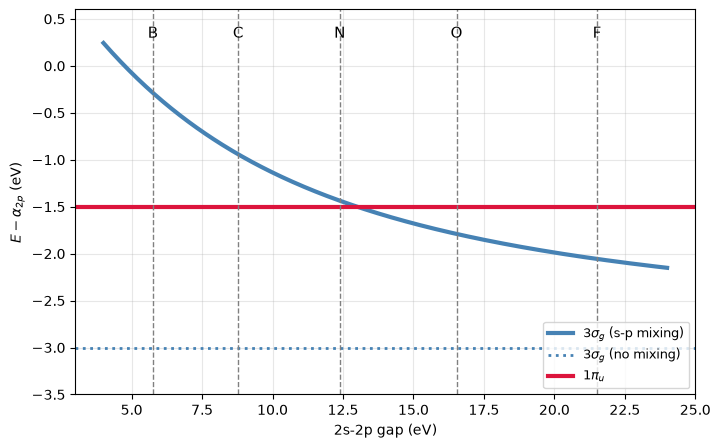

In [3]:
import numpy as np
import matplotlib.pyplot as plt

b_ss, b_pp, b_pi, b_sp = -2.0, -3.0, -1.5, -4.5  # eV, 대략적인 값

gaps = np.linspace(4, 24, 400)
E_3sg = []
for g in gaps:
    a_s, a_p = -g, 0.0
    H = np.array([[a_s + b_ss, b_sp], [b_sp, a_p + b_pp]])
    E = np.linalg.eigvalsh(H)
    E_3sg.append(E[1])
E_pi = 0.0 + b_pi

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gaps, E_3sg, lw=3, color="steelblue", label=r"$3\sigma_g$ (s-p mixing)")
ax.axhline(0.0 + b_pp, color="steelblue", ls=":", lw=2, label=r"$3\sigma_g$ (no mixing)")
ax.axhline(E_pi, color="crimson", lw=3, label=r"$1\pi_u$")
for el in alpha_2s:
    g = alpha_2p[el] - alpha_2s[el]
    ax.axvline(g, color="gray", ls="--", lw=1)
    ax.text(g, 0.3, el, ha="center", fontsize=11)
ax.set_ylim(-3.5, 0.6)
ax.set_xlabel("2s-2p gap (eV)")
ax.set_ylabel(r"$E - \alpha_{2p}$ (eV)")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
plt.show()